# 

In [2]:
import awkward as ak
import vector
vector.register_awkward()
import numpy as np
import matplotlib
import matplotlib.pyplot as plt
import hist
import mplhep as hep
import pandas as pd
hep.style.ROOT
import matplotlib.cm as cm
import sys
sys.path.insert(0, '../scripts')
from plotting import *
from common_defs import *
print(matplotlib.__version__)

%load_ext autoreload
%autoreload 2

Masking out zero values to fix different lengths:  (100000,) (100000,) (99996,)
Masking out zero values to fix different lengths:  (100000,) (100000,) (99996,)
Masking out zero values to fix different lengths:  (100000,) (100000,) (99996,)
TTbar frac values [0.   0.   0.25 0.42 0.53 0.94]
TTbar jeppe v0 frac values [-0.64, -0.63, -0.62, -0.61, -0.59, -0.58, -0.56, -0.53, -0.51, -0.48, -0.45, -0.41, -0.37, -0.33, -0.3, -0.25, -0.21, -0.16, -0.11, -0.05, -0.0, 0.05, 0.1, 0.15, 0.2, 0.25, 0.31, 0.35, 0.4, 0.45, 0.49, 0.54, 0.57, 0.61, 0.65, 0.68, 0.72, 0.74, 0.77, 0.79, 0.82, 0.84, 0.86, 0.88, 0.89, 0.91, 0.92, 0.93, 0.94, 0.95]
3.10.8


In [3]:
zjj_jets = ak.from_parquet(lhayDir + '/zjj_NLO_100k_eta4p5_NOLEP.parquet')
order = ak.argsort(zjj_jets.pt, axis=1, ascending=False)
zjets = zjj_jets[order]
####load hp points to repopulate weights where the event==0 and those weights were not computed
hp_points = np.load(rjainDir + "/ppzjj_100k/hardprocess_points.npy")
####Load z coords
zpt = np.load(rjainDir + '/ppzjj_100k/ppzjj_NLO_100k_zcoords.npy')[:,0]
zeta = np.load(rjainDir + '/ppzjj_100k/ppzjj_NLO_100k_zcoords.npy')[:,1]
zphi = np.load(rjainDir + '/ppzjj_100k/ppzjj_NLO_100k_zcoords.npy')[:,2]


#### Here lies plots for Z_jet events. Edit styles in plotting.py.

In [4]:
obsDict = {}
njets = max(ak.num(zjets.pt, axis=1))

nosel = (ak.num(zjets.pt, axis=1)>-5)

sel_twojets = (ak.num(zjets.pt, axis=1)>1)
sel_jets_twojets = zjets[sel_twojets]

sel_onejet = (ak.num(zjets.pt, axis=1)>0)
sel_jets_onejet = zjets[sel_onejet]
# obsDict["drjj"] = {"name": r"\Delta R_{j_0, j_1}", "units": "", "xmin": 0, "xmax": 10, "numbins": 20, "ratioLim": [0.45,1.55], "obs": np.sqrt((sel_jets_twojets.eta[:,0] - sel_jets_twojets.eta[:,1])**2 + (sel_jets_twojets.phi[:,0] - sel_jets_twojets.phi[:,1])**2), "sel":sel_twojets, "logx":False, "ymin":2e-5, "ymax": 5e0, "logy": True, "binwnorm":None}
# obsDict["drzj"] = {"name": r"\Delta R_{Z, j_0}","units": "", "xmin": 0, "xmax": 6.5, "numbins": 20, "ratioLim": [0.7, 1.3], "obs": np.sqrt((zeta[sel_onejet] - sel_jets_onejet.eta[:,0])**2 + (zphi[sel_onejet] - sel_jets_onejet.phi[:,0])**2), "sel":sel_onejet, "logx":False, "ymin":6e-3, "ymax": 2e0, "logy": True, "binwnorm":None}
# obsDict["njets"] = {"name": r'N_{\mathrm{jets}}',"units": "", "xmin": 0, "xmax": njets, "numbins": njets, "ratioLim": [0.7, 1.3], "obs": ak.num(zjets.pt, axis=1), "sel":nosel, "logx":False, "ymin":2e-5, "ymax": 8e0, "logy": True, "binwnorm":None}
# obsDict["ptlead"] = {"name": r'p_{\mathrm{T},j_0}',"units": r"\mathrm{[GeV]}", "xmin": 20, "xmax": 150, "numbins": 20, "ratioLim": [0.45,1.55], "obs": sel_jets_onejet.pt[:,0], "sel": sel_onejet, "logx":False, "ymin":3e-3, "ymax": 8e-1, "logy": True, "binwnorm":None}
# obsDict["ht"] = {"name": r'H_\mathrm{T}',"units": r"\mathrm{[GeV]}", "xmin": 50, "xmax": 700, "numbins": 25, "ratioLim": [0.7,1.3], "obs": ak.sum(zjets.pt, axis=-1), "sel": nosel, "logx":True, "ymin":3e-3, "ymax": 5e-1, "logy": True, "binwnorm":None}
# obsDict["zpt"] = {"name": r'p_{\mathrm{T},Z}',"units": r"\mathrm{[GeV]}", "xmin": 10, "xmax": 350, "numbins": 20, "ratioLim": [0.7,1.3], "obs": zpt, "sel": nosel, "logx":True, "ymin":1e-3, "ymax": 5e-1, "logy": True, "binwnorm":None}
# obsDict["ptrat"] = {"name": r"p_{\mathrm{T}0}/p_{\mathrm{T}1}","units": "", "xmin": 1, "xmax": 4.0, "numbins": 14, "ratioLim": [0.45,1.55], "obs": sel_jets_twojets.pt[:,0]/sel_jets_twojets.pt[:,1], "sel": sel_twojets, "logx":False, "ymin":1.1e-4, "ymax": 2e0, "logy": True, "binwnorm":None}

obsDict["drjj"] = {"name": r"\Delta R_{j_0, j_1}", "units": "", "xmin": 0, "xmax": 10, "numbins": 20, "ratioLim": [0.45,1.55], "obs": np.sqrt((sel_jets_twojets.eta[:,0] - sel_jets_twojets.eta[:,1])**2 + (sel_jets_twojets.phi[:,0] - sel_jets_twojets.phi[:,1])**2), "sel":sel_twojets, "logx":False, "ymin":2e-5, "ymax": 5e0, "logy": True, "binwnorm":True}
obsDict["drzj"] = {"name": r"\Delta R_{Z, j_0}","units": "", "xmin": 0, "xmax": 6.5, "numbins": 20, "ratioLim": [0.7, 1.3], "obs": np.sqrt((zeta[sel_onejet] - sel_jets_onejet.eta[:,0])**2 + (zphi[sel_onejet] - sel_jets_onejet.phi[:,0])**2), "sel":sel_onejet, "logx":False, "ymin":6e-3, "ymax": 2e0, "logy": True, "binwnorm":True}
obsDict["njets"] = {"name": r'N_{\mathrm{jets}}',"units": "", "xmin": 0, "xmax": njets, "numbins": njets, "ratioLim": [0.8, 1.2], "obs": ak.num(zjets.pt, axis=1), "sel":nosel, "logx":False, "ymin":2e-5, "ymax": 8e0, "logy": True, "binwnorm":True}
obsDict["ptlead"] = {"name": r'p_{\mathrm{T},j_0}',"units": r"\mathrm{[GeV]}", "xmin": 20, "xmax": 150, "numbins": 20, "ratioLim": [0.8,1.2], "obs": sel_jets_onejet.pt[:,0], "sel": sel_onejet, "logx":False, "ymin":3e-4, "ymax": 1e-1, "logy": True, "binwnorm":True}
obsDict["ht"] = {"name": r'H_\mathrm{T}',"units": r"\mathrm{[GeV]}", "xmin": 50, "xmax": 700, "numbins": 25, "ratioLim": [0.9,1.1], "obs": ak.sum(zjets.pt, axis=-1), "sel": nosel, "logx":True, "ymin":2e-5, "ymax": 1e-1, "logy": True, "binwnorm":True}
obsDict["zpt"] = {"name": r'p_{\mathrm{T},Z}',"units": r"\mathrm{[GeV]}", "xmin": 10, "xmax": 350, "numbins": 20, "ratioLim": [0.8,1.2], "obs": zpt, "sel": nosel, "logx":True, "ymin":2e-5, "ymax": 2e-1, "logy": True, "binwnorm":True}
obsDict["ptrat"] = {"name": r"p_{\mathrm{T}0}/p_{\mathrm{T}1}","units": "", "xmin": 1, "xmax": 4.0, "numbins": 14, "ratioLim": [0.6,1.4], "obs": sel_jets_twojets.pt[:,0]/sel_jets_twojets.pt[:,1], "sel": sel_twojets, "logx":False, "ymin":3e-3, "ymax": 7, "logy": True, "binwnorm":True}



In [5]:
processDict = {}
processDict["Zjets"] = {"name": "Z+jets", "weights": weights_orig_z}

In [6]:
comparisonDict = {}

comparisonDict["stages"] = {"weights": ["zjet_hp_df", "zjet_ps_df", "zjet_had_df"], "maxCellRadius": 30}
comparisonDict["betasHad"] = {"weights": ["zjet_b0_had_df", "zjet_b0p5_had_df", "zjet_had_df", "zjet_b2_had_df",  "zjet_binf_had_df"], "maxCellRadius": 250}
# comparisonDict["betasHp"] = {"weights": ["zjet_b0_hp_df", "zjet_b0p5_hp_df", "zjet_hp_df", "zjet_b2_hp_df",  "zjet_binf_hp_df"], "maxCellRadius": 250}
comparisonDict["semdVemd_Had"] = {"weights": ["zjet_SEMD_had_df", "zjet_had_df", "zjet_jeppeV3_df"], "maxCellRadius": 50}
# comparisonDict["JeppComp_Had"] = {"weights": ["zjet_jeppeV1_df", "zjet_jeppeV0_df", "zjet_jeppeV2_df" , "zjet_jeppeV3_df"], "maxCellRadius": 50}

# comparisonDict["stagesBeta0"] = {"weights": ["zjet_b0_hp_df", "zjet_b0_ps_df", "zjet_b0_had_df"], "maxCellRadius": 30}
# comparisonDict["stagesBetap5"] = {"weights": ["zjet_b0p5_ps_df", "zjet_b0p5_hp_df", "zjet_b0p5_had_df"], "maxCellRadius": 100}
# comparisonDict["stagesBeta2"] = {"weights": ["zjet_b2_hp_df", "zjet_b2_ps_df", "zjet_b2_had_df"], "maxCellRadius": 3}

# comparisonDict["betasHP"] = {"weights": ["zjet_b0_hp_df", "zjet_b0p5_hp_df", "zjet_hp_df", "zjet_b2_hp_df",  "zjet_binf_hp_df"], "maxCellRadius": 250}
# comparisonDict["betasPS"] = {"weights": ["zjet_b0_ps_df", "zjet_b0p5_ps_df", "zjet_ps_df", "zjet_b2_ps_df",  "zjet_binf_ps_df"], "maxCellRadius": 250}

#comparisonDict["semdVemd_HP"] = {"weights": ["zjet_SEMD_hp_df", "zjet_hp_df", "zjet_SEMD_cm"], "maxCellRadius": 50}
#comparisonDict["semdVemd_PS"] = {"weights": ["zjet_SEMD_ps_df", "zjet_ps_df"], "maxCellRadius": 50}

#comparisonDict["semdStages"] = {"weights": ["zjet_SEMD_hp_df", "zjet_SEMD_ps_df", "zjet_SEMD_had_df", "zjet_SEMD_cm"], "maxCellRadius": 250}
#comparisonDict["semdp1Stages"] = {"weights": ["zjet_SEMD_hp_df", "zjet_SEMD_ps_df", "zjet_SEMD_had_df"], "maxCellRadius": 0.02}



/oscar/home/lhay/negweights/lib/python3.10/site-packages/mplhep/utils.py:652: RuntimeWarning: All sumw are zero!  Cannot compute meaningful error bars
  return np.abs(method_fcn(self.values(), variances) - self.values())
/tmp/ipykernel_2787979/1365534248.py:13: UserWarning: Data has no positive values, and therefore cannot be log-scaled.
  ax.set_yscale("log")


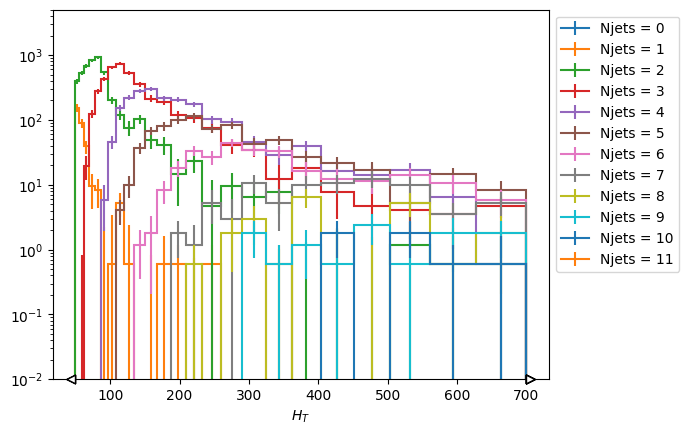

In [7]:
# logbins = np.logspace(np.log10(50), np.log10(700), 25)
# axis_njet = hist.axis.Regular(njets,0, njets,name="njet",label="njet",)
# axis_ht = hist.axis.Variable(logbins,name="ht",label=r"$H_T$",)
# fig, ax = plt.subplots()
# h_orig = hist.Hist(
#         axis_njet, axis_ht,
#         storage=hist.storage.Weight(), )
# htdict = obsDict["ht"]
# njetdict = obsDict["njets"]
# h_orig.fill(ht=htdict["obs"], njet = njetdict["obs"], weight = weights_orig_z)
# for i in range(njets):
#     hep.histplot(h_orig[{"njet":i}], ax=ax, label=f"Njets = {i}")
#     ax.set_yscale("log")
#     ax.set_ylim(1e-2, 5e3)
#     ax.legend(loc='upper left', bbox_to_anchor=(1.0, 1.0))

/oscar/home/lhay/negweights/lib/python3.10/site-packages/mplhep/utils.py:652: RuntimeWarning: All sumw are zero!  Cannot compute meaningful error bars
  return np.abs(method_fcn(self.values(), variances) - self.values())
/tmp/ipykernel_2787979/4089505637.py:13: UserWarning: Data has no positive values, and therefore cannot be log-scaled.
  ax.set_yscale("log")


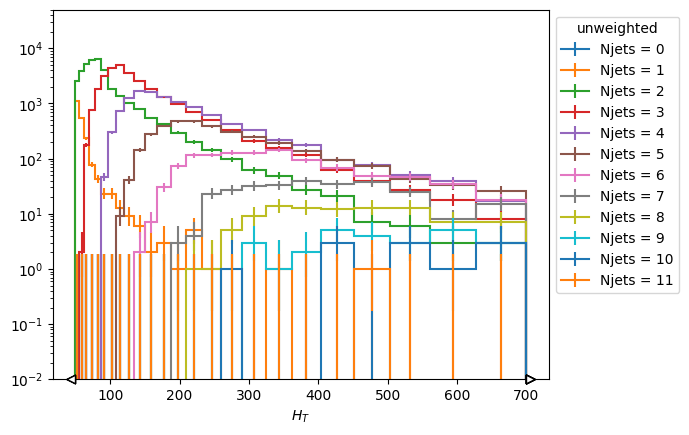

In [8]:
# logbins = np.logspace(np.log10(50), np.log10(700), 25)
# axis_njet = hist.axis.Regular(njets,0, njets,name="njet",label="njet",)
# axis_ht = hist.axis.Variable(logbins,name="ht",label=r"$H_T$",)
# fig, ax = plt.subplots()
# h_orig = hist.Hist(
#         axis_njet, axis_ht,
#         storage=hist.storage.Weight(), )
# htdict = obsDict["ht"]
# njetdict = obsDict["njets"]
# h_orig.fill(ht=htdict["obs"], njet = njetdict["obs"])
# for i in range(njets):
#     hep.histplot(h_orig[{"njet":i}], ax=ax, label=f"Njets = {i}")
#     ax.set_yscale("log")
#     ax.set_ylim(1e-2, 5e4)
#     ax.legend(loc='upper left', bbox_to_anchor=(1.0, 1.0), title="unweighted")

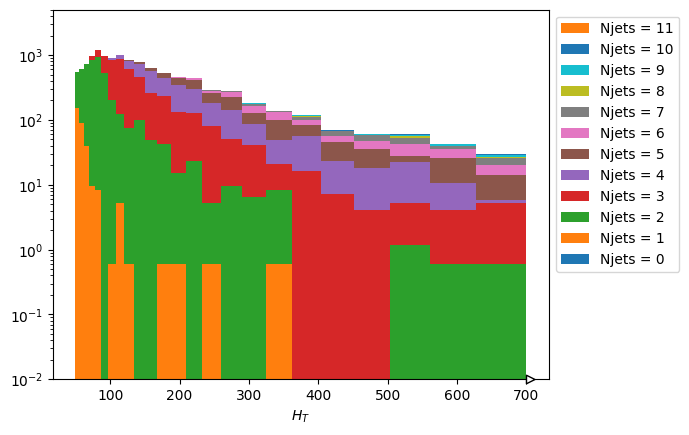

In [9]:
# logbins = np.logspace(np.log10(50), np.log10(700), 25)
# axis_njet = hist.axis.Regular(njets,0, njets,name="njet",label="njet",)
# axis_ht = hist.axis.Variable(logbins,name="ht",label=r"$H_T$",)
# fig, ax = plt.subplots()
# h_orig = hist.Hist(
#         axis_njet, axis_ht,
#         storage=hist.storage.Weight(), )
# htdict = obsDict["ht"]
# njetdict = obsDict["njets"]
# h_orig.fill(ht=htdict["obs"], njet = njetdict["obs"], weight = weights_orig_z)
# slices = [h_orig[{"njet":i}] for i in range(njets)]
# hep.histplot(slices, ax=ax, label=[f"Njets = {i}" for i in range(njets)], stack=True, histtype="fill")
# ax.set_yscale("log")
# ax.set_ylim(1e-2, 5e3)
# ax.legend(loc='upper left', bbox_to_anchor=(1.0, 1.0))

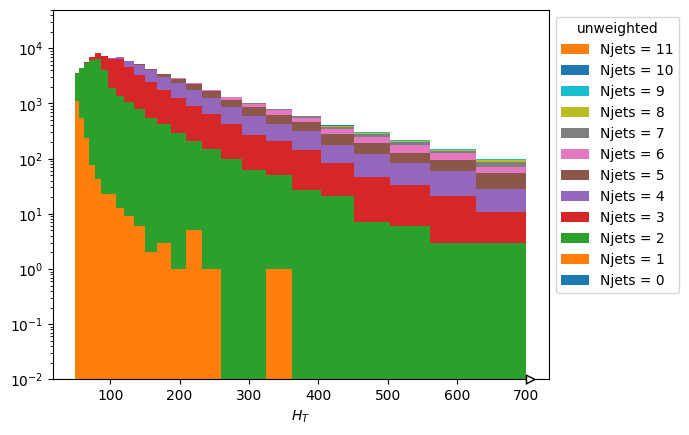

In [10]:
# logbins = np.logspace(np.log10(50), np.log10(700), 25)
# axis_njet = hist.axis.Regular(njets,0, njets,name="njet",label="njet",)
# axis_ht = hist.axis.Variable(logbins,name="ht",label=r"$H_T$",)
# fig, ax = plt.subplots()
# h_orig = hist.Hist(
#         axis_njet, axis_ht,
#         storage=hist.storage.Weight(), )
# htdict = obsDict["ht"]
# njetdict = obsDict["njets"]
# h_orig.fill(ht=htdict["obs"], njet = njetdict["obs"])
# slices = [h_orig[{"njet":i}] for i in range(njets)]
# hep.histplot(slices, ax=ax, label=[f"Njets = {i}" for i in range(njets)], stack=True, histtype="fill")
# ax.set_yscale("log")
# ax.set_ylim(1e-2, 5e4)
# ax.legend(loc='upper left', bbox_to_anchor=(1.0, 1.0), title="unweighted")

In [11]:
# logbins = np.logspace(np.log10(50), np.log10(700), 25)
# axis_njet = hist.axis.Regular(njets,0, njets,name="njet",label="njet",)
# axis_ht = hist.axis.Variable(logbins,name="ht",label=r"$H_T$",)
# h_orig = hist.Hist(
#         axis_njet, axis_ht,
#         storage=hist.storage.Weight(), )
# htdict = obsDict["ht"]
# njetdict = obsDict["njets"]
# h_orig.fill(ht=htdict["obs"], njet = njetdict["obs"], weight = weights_orig_z)
# for i in range(njets):
#     fig, ax = plt.subplots()
#     hep.histplot(h_orig[{"njet":i}], ax=ax, label=f"Njets = {i}")
#     ax.set_yscale("log")
#     ax.set_ylim(1e-2, 5e3)
#     ax.legend()

In [12]:
from plotting import *
for comparison in comparisonDict:
    rw_dict_strings = comparisonDict[comparison]["weights"]
    datasets = []
    for sample in rw_dict_strings:
        datasets.append(dataFrames[sample])
            
    directory = f"../plots/radius"
    plot_radii(datasets, directory, comparison, comparisonDict)
    

$\beta=1$ HS  R for 0.75 RW  12.435
$\beta=1$ HS  R for 0.5 RW  9.11
$\beta=1$ HS  R for 0.25 RW  6.454
$\beta=1$ PS  R for 0.75 RW  16.697
$\beta=1$ PS  R for 0.5 RW  12.385
$\beta=1$ PS  R for 0.25 RW  8.94
$\beta=1$ HAD  R for 0.75 RW  16.607
$\beta=1$ HAD  R for 0.5 RW  12.722
$\beta=1$ HAD  R for 0.25 RW  9.618
../plots/radius/radii_stages
$\beta=0$ HAD R for 0.75 RW  215.203
$\beta=0$ HAD R for 0.5 RW  174.178
$\beta=0$ HAD R for 0.25 RW  141.405
$\beta=0.5$ HAD R for 0.75 RW  52.695
$\beta=0.5$ HAD R for 0.5 RW  41.804
$\beta=0.5$ HAD R for 0.25 RW  33.103
$\beta=1$ HAD  R for 0.75 RW  16.607
$\beta=1$ HAD  R for 0.5 RW  12.722
$\beta=1$ HAD  R for 0.25 RW  9.618
$\beta= 2$ HAD R for 0.75 RW  1.586
$\beta= 2$ HAD R for 0.5 RW  1.374
$\beta= 2$ HAD R for 0.25 RW  1.204
$\beta=\infty$ HAD R for 0.75 RW  0.009
$\beta=\infty$ HAD R for 0.5 RW  0.005
$\beta=\infty$ HAD R for 0.25 RW  0.003
../plots/radius/radii_betasHad
SEMD p=1 HAD R for 0.75 RW  0.002
SEMD p=1 HAD R for 0.5 RW  0.0

<Figure size 640x480 with 0 Axes>

<Figure size 640x480 with 0 Axes>

<Figure size 640x480 with 0 Axes>

In [13]:
# rwFracs = [0.25, 0.75]
# for comparison in comparisonDict:
#     for observable in obsDict:
#         for rwFrac in rwFracs:
#             rw_dict_strings = comparisonDict[comparison]["weights"]

#             processes = []
#             datasets = []
#             for sample in rw_dict_strings:
#                 datasets.append(dataFrames[sample])
#                 processes.append(dataFrames[sample]["process"])

#             processWeights = processDict[processes[0]]["weights"]
#             processTitle = processDict[processes[0]]["name"]
#             isSameProcess = True
#             for process in processes:
#                 if process != processes[0]:
#                     print("Mixed processes -- this script requires rewriting to work in this context")
#                     isSameProcess= False
#                     break
#             if not isSameProcess:
#                 break


#             ax, leg = plot_diff_rw(obsDict[observable], datasets, processWeights, process_title = processTitle, title = comparison, channel = processes[0], rwFrac=rwFrac, obsName = observable)
#             # leg.set_title(r"Jet $\eta$ < 4.5 NO LEP")

       

In [17]:
from common_defs import *
for comparison in comparisonDict:
    rw_dict_strings = comparisonDict[comparison]["weights"]
    neg_percents = []
    datasets = []
    variances = []
    processWeights = processDict[dataFrames[sample]["process"]]["weights"]
    for sample in rw_dict_strings:
        datasets.append(dataFrames[sample])
        neg_percent = get_negative_percent(processWeights, dataFrames[sample]["df"]["weights"])
        variance = [np.var(np.asarray(i)/14550) for i in dataFrames[sample]["df"]["weights"]]
        orig_variance = np.var(processWeights)
        if(neg_percent[0] < 1e-3):
            neg_percent = neg_percent[1:]
            variance = variance[1:]
        variances.append(variance/orig_variance)
        neg_percents.append(neg_percent)

        
    plot_variance(neg_percents, variances, datasets, title=comparison)


../plots/dilution/variance_stages
../plots/dilution/variance_betasHad
../plots/dilution/variance_semdVemd_Had


<Figure size 640x480 with 0 Axes>

<Figure size 640x480 with 0 Axes>

<Figure size 640x480 with 0 Axes>

In [20]:
for comparison in comparisonDict:
    rw_dict_strings = comparisonDict[comparison]["weights"]

    neg_percents = []
    dilutions = []
    datasets = []
    for sample in rw_dict_strings:
        datasets.append(dataFrames[sample])
        neg_percent = get_negative_percent(processDict[dataFrames[sample]["process"]]["weights"], dataFrames[sample]["df"]["weights"])
        dilution = get_dilution(dataFrames[sample]["df"]["weights"])
        # Get the index of the closest value
        idx = np.abs(np.array(neg_percent) - 0.25).argmin()
        # Retrieve the actual value
        print(dilution[idx])
        print(dilution[0])
        print((dilution[0]-dilution[idx])/dilution[idx])
        if(neg_percent[0] < 1e-3):
            neg_percent = neg_percent[1:]
            dilution = dilution[1:]
        neg_percents.append(neg_percent)
        dilutions.append(dilution)
        processTitle = processDict[dataFrames[sample]["process"]]["name"]
        
    plot_dilution(neg_percents, dilutions, datasets, title=comparison, process_title = processTitle)



12.77961850266921
14.479466156505815
0.13301239418700694
13.087059969606546
15.67405170814925
0.19767554703277485
12.755660450231133
16.20896084513684
0.27072689872699873
$\beta=1$ HS : 1/f_ESS = -12.6302*f_rw + 16.0327  (m_err=0.0495, b_err=0.0348)
For 0.25 RW, new stat cost is 12.875193650208168, corresponding to 0.19694407029419814
For 0.5 RW, new stat cost is 9.717638927678497, corresponding to 0.39388814058839616
For total RW, new stat cost is 3.4025294826191548, corresponding to 0.7877762811767923
$\beta=1$ PS : 1/f_ESS = -12.6695*f_rw + 16.1307  (m_err=0.0370, b_err=0.0225)
For 0.25 RW, new stat cost is 12.963346458984832, corresponding to 0.1963571012555907
For 0.5 RW, new stat cost is 9.795963113427838, corresponding to 0.3927142025111814
For total RW, new stat cost is 3.4611964223138525, corresponding to 0.7854284050223626
$\beta=1$ HAD : 1/f_ESS = -12.5252*f_rw + 16.0256  (m_err=0.0077, b_err=0.0054)
For 0.25 RW, new stat cost is 12.89431896514181, corresponding to 0.1953935

<Figure size 640x480 with 0 Axes>

<Figure size 640x480 with 0 Axes>

<Figure size 640x480 with 0 Axes>

In [ ]:
##### plot multiple RW fraactions for the same sample
obsDict["drjj"] = {"name": r"\Delta R_{j_0, j_1}", "units": "", "xmin": 0, "xmax": 10, "numbins": 20, "ratioLim": [0.5,1.5], "obs": np.sqrt((sel_jets_twojets.eta[:,0] - sel_jets_twojets.eta[:,1])**2 + (sel_jets_twojets.phi[:,0] - sel_jets_twojets.phi[:,1])**2), "sel":sel_twojets, "logx":False, "ymin":2e-5, "ymax": 5e0, "logy": True, "binwnorm":True}
obsDict["drzj"] = {"name": r"\Delta R_{Z, j_0}","units": "", "xmin": 0, "xmax": 6.5, "numbins": 20, "ratioLim": [0.5,1.5], "obs": np.sqrt((zeta[sel_onejet] - sel_jets_onejet.eta[:,0])**2 + (zphi[sel_onejet] - sel_jets_onejet.phi[:,0])**2), "sel":sel_onejet, "logx":False, "ymin":6e-3, "ymax": 2e0, "logy": True, "binwnorm":True}
obsDict["njets"] = {"name": r'N_{\mathrm{jets}}',"units": "", "xmin": 0, "xmax": njets, "numbins": njets, "ratioLim": [0.5,1.5], "obs": ak.num(zjets.pt, axis=1), "sel":nosel, "logx":False, "ymin":2e-5, "ymax": 8e0, "logy": True, "binwnorm":True}
obsDict["ptlead"] = {"name": r'p_{\mathrm{T},j_0}',"units": r"\mathrm{[GeV]}", "xmin": 20, "xmax": 150, "numbins": 20, "ratioLim": [0.5,1.5], "obs": sel_jets_onejet.pt[:,0], "sel": sel_onejet, "logx":False, "ymin":3e-4, "ymax": 1e-1, "logy": True, "binwnorm":True}
obsDict["ht"] = {"name": r'H_\mathrm{T}',"units": r"\mathrm{[GeV]}", "xmin": 50, "xmax": 700, "numbins": 25, "ratioLim": [0.5,1.5], "obs": ak.sum(zjets.pt, axis=-1), "sel": nosel, "logx":True, "ymin":2e-5, "ymax": 1e-1, "logy": True, "binwnorm":True}
obsDict["zpt"] = {"name": r'p_{\mathrm{T},Z}',"units": r"\mathrm{[GeV]}", "xmin": 10, "xmax": 350, "numbins": 20, "ratioLim": [0.5,1.5], "obs": zpt, "sel": nosel, "logx":True, "ymin":2e-5, "ymax": 2e-1, "logy": True, "binwnorm":True}
obsDict["ptrat"] = {"name": r"p_{\mathrm{T}0}/p_{\mathrm{T}1}","units": "", "xmin": 1, "xmax": 4.0, "numbins": 14, "ratioLim": [0.5,1.5], "obs": sel_jets_twojets.pt[:,0]/sel_jets_twojets.pt[:,1], "sel": sel_twojets, "logx":False, "ymin":3e-3, "ymax": 7, "logy": True, "binwnorm":True}


for comparison in comparisonDict:
    print(comparison)
    rw_dict_strings = comparisonDict[comparison]["weights"]
    for sample in rw_dict_strings:
        print(sample)
        dataset = dataFrames[sample]
        process = dataFrames[sample]["process"]
        rw_dict_strings = comparisonDict[comparison]["weights"]
        for observable in obsDict:
            plot_same_rw_all(obsDict[observable], dataset["df"], weights_orig_z)


In [ ]:
jets_highstat = ak.from_parquet('/oscar/data/mleblan6/rjain/ppzjj_10M/ppzjj_NLO_10M_alljet.parquet')
order = ak.argsort(jets_highstat.pt, axis=1, ascending=False)
zjets_hs = jets_highstat[order]

####Load z coords
zpt = np.load('/oscar/data/mleblan6/rjain/ppzjj_10M/ppzjj_NLO_10M_zcoords.npy')[:,0]
zeta = np.load('/oscar/data/mleblan6/rjain/ppzjj_10M/ppzjj_NLO_10M_zcoords.npy')[:,1]
zphi = np.load('/oscar/data/mleblan6/rjain/ppzjj_10M/ppzjj_NLO_10M_zcoords.npy')[:,2]


weights_orig_highstat = np.load("/oscar/data/mleblan6/rjain/ppzjj_10M/ppzjj_NLO_10M_weight.npy")


obsDict_highstat = {}

njets = max(ak.num(zjets_hs.pt, axis=1))

nosel = (ak.num(zjets_hs.pt, axis=1)>-5)

sel_twojets = (ak.num(zjets_hs.pt, axis=1)>1)
sel_jets_twojets = zjets_hs[sel_twojets]

sel_onejet = (ak.num(zjets_hs.pt, axis=1)>0)
sel_jets_onejet = zjets_hs[sel_onejet]

obsDict_highstat["drjj"] = {"name": r"\Delta R_{j_0, j_1}", "units": "", "xmin": 0, "xmax": 10, "numbins": 20, "ratioLim": [0.45,1.55], "obs": np.sqrt((sel_jets_twojets.eta[:,0] - sel_jets_twojets.eta[:,1])**2 + (sel_jets_twojets.phi[:,0] - sel_jets_twojets.phi[:,1])**2), "sel":sel_twojets, "logx":False, "ymin":2e-5, "ymax": 5e0}
obsDict_highstat["drzj"] = {"name": r"\Delta R_{Z, j_0}","units": "", "xmin": 0, "xmax": 6.5, "numbins": 20, "ratioLim": [0.8, 1.2], "obs": np.sqrt((zeta[sel_onejet] - sel_jets_onejet.eta[:,0])**2 + (zphi[sel_onejet] - sel_jets_onejet.phi[:,0])**2), "sel":sel_onejet, "logx":False, "ymin":6e-3, "ymax": 2e0}
obsDict_highstat["njets"] = {"name": r'N_{\mathrm{jets}}',"units": "", "xmin": 0, "xmax": njets, "numbins": njets, "ratioLim": [0.5, 1.5], "obs": ak.num(zjets_hs.pt, axis=1), "sel":nosel, "logx":False, "ymin":2e-5, "ymax": 6e0}
obsDict_highstat["ptlead"] = {"name": r'p_{\mathrm{T},j_0}',"units": r"\mathrm{[GeV]}", "xmin": 20, "xmax": 150, "numbins": 20, "ratioLim": [0.45,1.55], "obs": sel_jets_onejet.pt[:,0], "sel": sel_onejet, "logx":False, "ymin":3e-3, "ymax": 8e-1}
obsDict_highstat["ht"] = {"name": r'H_\mathrm{T}',"units": r"\mathrm{[GeV]}", "xmin": 50, "xmax": 700, "numbins": 20, "ratioLim": [0.75,1.25], "obs": ak.sum(zjets.pt, axis=-1), "sel": nosel, "logx":True, "ymin":3e-3, "ymax": 5e-1}
obsDict_highstat["zpt"] = {"name": r'p_{\mathrm{T},Z}',"units": r"\mathrm{[GeV]}", "xmin": 10, "xmax": 350, "numbins": 20, "ratioLim": [0.75,1.25], "obs": zpt, "sel": nosel, "logx":True, "ymin":1e-3, "ymax": 5e-1}
obsDict_highstat["ptrat"] = {"name": r"p_{\mathrm{T}0}/p_{\mathrm{T}1}","units": "", "xmin": 1, "xmax": 4.0, "numbins": 14, "ratioLim": [0.45,1.55], "obs": sel_jets_twojets.pt[:,0]/sel_jets_twojets.pt[:,1], "sel": sel_twojets, "logx":False, "ymin":1.1e-4, "ymax": 2e0}

In [ ]:
rwFracs = [0.25, 0.5, 0.75]
observable = "njets"
logy=True
weights = [weights_orig_z, weights_orig_highstat]
logx = obsDict[observable]["logx"]
xmin = obsDict[observable]["xmin"]
xmax = obsDict[observable]["xmax"]
ymin = obsDict[observable]["ymin"]
ymax = obsDict[observable]["ymax"]
nbins = obsDict[observable]["numbins"]
obs_str = obsDict[observable]["name"]
obs = obsDict[observable]["obs"]
obs_hs = obsDict_highstat[observable]["obs"]
sel = np.array(obsDict[observable]["sel"])
sel_hs = np.array(obsDict_highstat[observable]["sel"])
ratioLim = obsDict[observable]["ratioLim"]
units = obsDict[observable]["units"]

jets_other = ak.from_parquet("/users/lhay/NegativeWeights/zjj_NLO_100k_alljetsNOLEP.parquet")
obs_other = ak.num(jets_other.pt, axis=1)


if logx:
    bins = np.logspace(np.log10(xmin), np.log10(xmax), nbins)
    axis_o = hist.axis.Variable(bins,name="data",label="orig",)
    axis_rw = hist.axis.Variable(bins,name="data",label="reweighted",)
else:
    axis_o = hist.axis.Regular(nbins,xmin, xmax,name="data",label="orig",)
    axis_rw = hist.axis.Regular(nbins,xmin, xmax,name="data",label="orig",)
if sel is None:
    sel  = np.ones_like(weights_orig_highstat, dtype=bool)
fig, ax = plt.subplots(nrows=1,
                    ncols=1,
                    figsize=(8,8),)
h_orig = hist.Hist(
    axis_o,
    storage=hist.storage.Weight(), )
h_orig.fill(obs, weight = weights_orig_z)
h_orig = h_orig/h_orig.sum(flow=False).value
hep.histplot(h_orig, ax=ax, label = "100K Original", color='blue')
h_orig_hs = hist.Hist(
    axis_o,
    storage=hist.storage.Weight(), )
h_orig_hs.fill(obs_hs, weight = weights_orig_highstat)
h_orig_hs = h_orig_hs/h_orig_hs.sum(flow=False).value
hep.histplot(h_orig_hs, ax=ax, label = "10M Original", color='black')
h_orig2 = hist.Hist(
    axis_o,
    storage=hist.storage.Weight(), )
h_orig2.fill(obs_other, weight = weights_orig_z)
h_orig2 = h_orig2/h_orig2.sum(flow=False).value
hep.histplot(h_orig2, ax=ax, label = "100k nolep", color='red')
ax.legend(frameon=False, fontsize=12, loc="upper right", borderpad=1.0)
ax.set_xlabel(r"$N_{jets}$")